# Copy Correction Procedure

Simplify the copy correction procedure and verify the normalization is properly handled.

**Motivation:** Previous copy correction procedure is incorrect, in that the goal is to make each timepoint equivalent. 

**Procedure:**
1. Normalize all samples by length distribution (and thus equal total number of reads)
2. For each 10k window, determine the replication time and copy number profile (computed from CLOCCS).
3. Reduce the count by half for replicated regions.
4. Question: Should we renormalize the samples? First intuition is, because the entirety of G2/M will now have half the number of reads compared to G1.


In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [171]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 6
span = (20000, 30000)
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)


In [170]:
from src.config import load_configs_by_config_type

# Proposed new copy correction procedure, take the replication time and the 
# proportion of cells in S/G2/M and divide by 2 for each corresponding timepoint...
# Hoping it makes the data look less wavey
config1, config2 = load_configs_by_config_type('shared')
(H1, _), (H2,  _) = config1.calcH_function(config1.intervals_wt1, config1.WT1_TIMEPOINTS), \
    config2.calcH_function(config2.intervals_wt1, config2.WT1_TIMEPOINTS)

chrom_replication_profile = pd.read_csv('data/replication_timing/yl_2019/chrom_replication_timing_shared.csv').set_index(
    ['chr', 'start'])


0

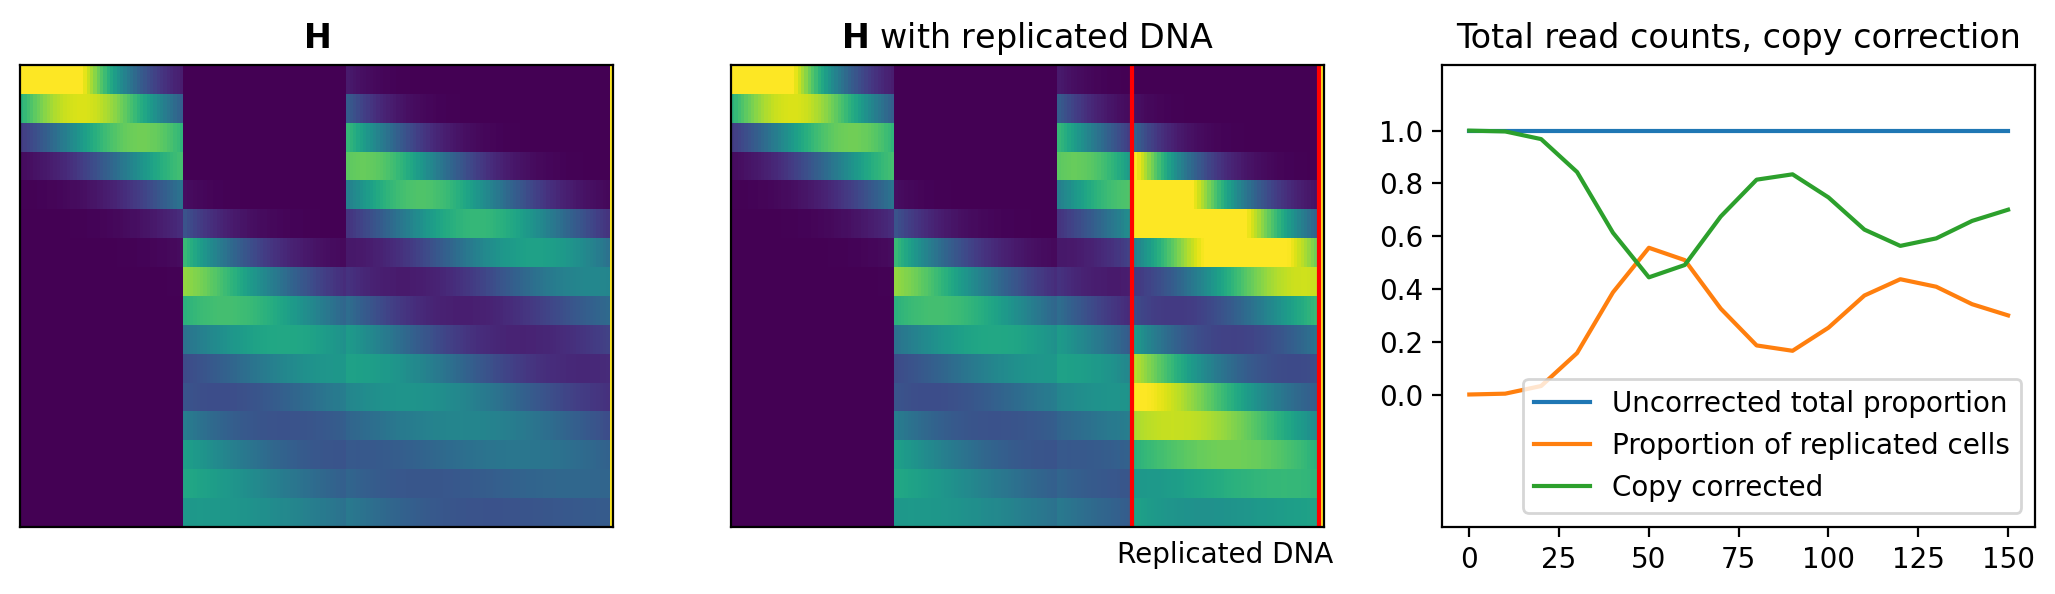

In [177]:
#plt.imshow(H1, vmax=0.01)

# Then, from replication until the end of G2/M, we will take this proportion of 
# reads and divide them by 2...

plt.figure(figsize=(13, 3))
plt.subplot(1, 3, 1)
plt.imshow(H1, vmax=0.02, aspect='auto')
plt.title("$\\bf{H}$")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)

end_g2m_idx = H1.shape[1]-2
replicated_proportion = np.zeros_like(H1)
replicated_proportion[:, replication_idx:end_g2m_idx] = H1[:, replication_idx:end_g2m_idx]
plt.imshow(H1+replicated_proportion, vmax=0.02, aspect='auto')
plt.title("$\\bf{H}$ with replicated DNA")
plt.xticks([(replication_idx+end_g2m_idx)/2], ["Replicated DNA"])
plt.yticks([])
plt.axvline(replication_idx, c='red', ls='solid')
plt.axvline(end_g2m_idx, c='red', ls='solid')
plt.gca().xaxis.set_tick_params(pad=5, length=0)

# We assume that the replicated proportion of DNA is included in the
# total number of reads, so normalize by the total proportion and the additional
# copy corrected DNA
total_uncorrected_sum = H1.sum(axis=1)
replicated_sum = replicated_proportion.sum(axis=1)
proportion_of_replicated_DNA = replicated_sum / (total_uncorrected_sum + replicated_sum)

plt.subplot(1, 3, 3)
timepoints = config1.WT1_TIMEPOINTS
plt.plot(timepoints, total_uncorrected_sum, label="Uncorrected total proportion")
plt.plot(timepoints, replicated_sum, label="Proportion of replicated cells")
plt.plot(timepoints, total_uncorrected_sum - replicated_sum, label="Copy corrected")

plt.ylim(-0.5, 1.25)
plt.title("Total read counts, copy correction")
plt.legend()
plt.yticks(np.arange(0, 1.2, 0.2))
0

In [ ]:
plt.plot(genome_deconvolution.combined_model.chrom1_model.uncorrected_G.sum(axis=1))
plt.plot(genome_deconvolution.combined_model.chrom2_model.uncorrected_G.sum(axis=1))

plt.title("Reads are normalized by overall genome read depth and length distribution")
plt.ylim(0, 20000)

In [174]:
replication_idx = chrom_replication_profile.loc[chrom].loc[span[0]].replication_index

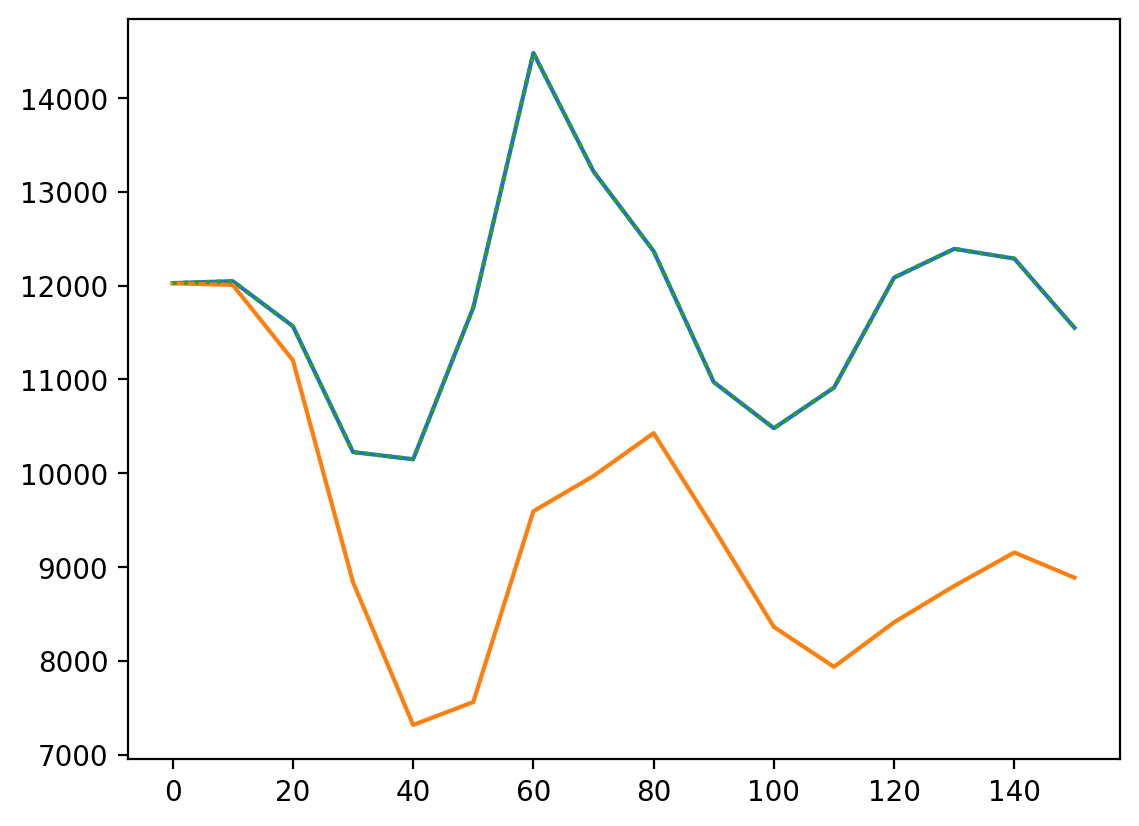

In [267]:
def perform_correction(uncorrected_reads, proportion_of_replicated_DNA):
    corrected_reads = uncorrected_reads - uncorrected_reads * proportion_of_replicated_DNA
    correction_scalar = corrected_reads / uncorrected_reads
    return uncorrected_reads, corrected_reads, correction_scalar
    
#uncorrected_reads = genome_deconvolution.combined_model.chrom1_model\
#    .uncorrected_G.sum(axis=1)

#uncorrected_reads, corrected_reads, correction_scalar = perform_correction(uncorrected_reads,
#    proportion_of_replicated_DNA)
plt.plot(timepoints, uncorrected_reads)
plt.plot(timepoints, uncorrected_reads*correction_scalar)

plt.plot(timepoints, normalized_1.sum(axis=1).sum(axis=1), ls='dotted')
#plt.plot(timepoints, normalized_2.sum(axis=1).sum(axis=1))

In [254]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
from src.timer import Timer

# Refactor such that we are computing the total reads the same way as the deconvolution 
# of the 10k windows is. That is load the reads into a histogram and normalize by length
# distribution prior to occupancy curves calculation.
#
# With the goal of reproducing the exact same total occupancy curve that the deconvolution
# of the 10k window produces...

all_10k_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv').set_index(['chr', 'start'])

chrom = 6
#genome_deconvolution = GenomeDeconvolution(save_dir=None)
timer = Timer()

for start, row in all_10k_windows.loc[chrom].iterrows():
    end = row.end
    
    start, end = span
    genome_deconvolution.load_chrom_span(chrom, span, log=False, downsample=False)
    
    print(start, end)
    timer.print_time()

    break
    

20000 30000
00:00:04.231


In [257]:
normalized_1 = genome_deconvolution.combined_model.chrom1_model.normalized_bins
normalized_2 = genome_deconvolution.combined_model.chrom2_model.normalized_bins


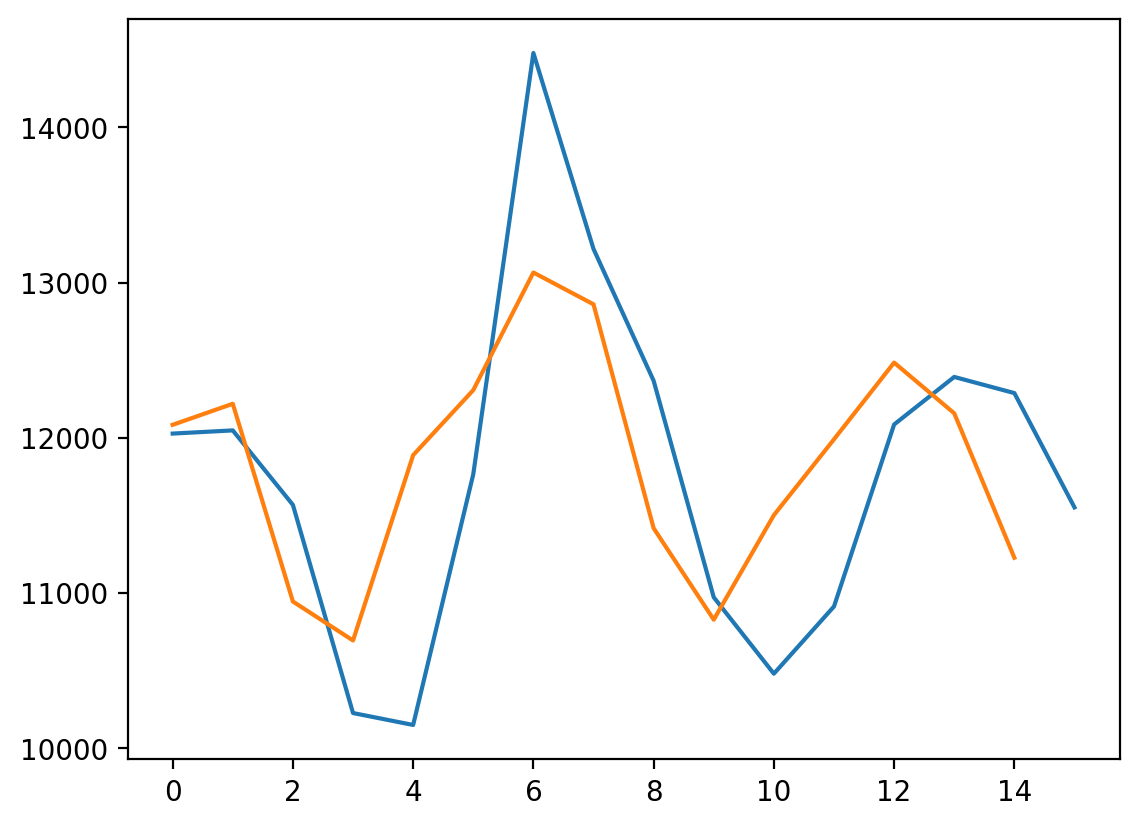

In [262]:
# Now that we have a way to iterate through all 10k windows quickly and compute
# the scalars for correction, we can also do analysis on the correction to sanity check
#
# 1. That the correction indeed is corrected and reducing the cyclicity of 
#    read counts approporiately
# 2. And that the deconvolved windows 
# 